# Federated Learning — Algorithm Comparison (500 Rounds)

Compares **Centralized (baseline), FedAvg, FedProx, SCAFFOLD, FedDC**.

| Cell | Dataset | Partition |
|------|---------|----------|
| Experiment 1 | CASAS | Non-IID |
| Experiment 2 | CASAS | IID |
| Experiment 3 | UCI   | IID |
| Experiment 4 | UCI   | Non-IID |

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from IPython.display import display

os.chdir("/home/clara/Research2.0/fyp_fl_smart_home")
print("CWD =", os.getcwd())

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.grid'         : True,
    'grid.alpha'        : 0.2,
    'grid.linestyle'    : '--',
    'axes.labelsize'    : 11,
    'axes.titlesize'    : 12,
    'xtick.labelsize'   : 9.5,
    'ytick.labelsize'   : 9.5,
    'legend.fontsize'   : 9.5,
    'legend.framealpha' : 0.92,
    'legend.edgecolor'  : '#cccccc',
    'figure.dpi'        : 140,
})

# ============================================================
# CONFIGURATION
# ============================================================
RESULTS_DIR = "results"
PLOTS_DIR   = os.path.join(RESULTS_DIR, "plots")
os.makedirs(PLOTS_DIR, exist_ok=True)

ALGOS  = ["fedavg", "fedprox", "scaffold", "feddc"]
MODEL  = "cnn"
ROUNDS = 500
SMOOTH = 12

ALGO_STYLES = {
    "centralized": {"color": "#2d3a8c", "ls": "-",            "lw": 2.5},
    "fedavg":      {"color": "#e53e3e", "ls": "--",           "lw": 1.9},
    "fedprox":     {"color": "#d97706", "ls": "-.",           "lw": 1.9},
    "scaffold":    {"color": "#38a169", "ls": ":",            "lw": 2.0},
    "feddc":       {"color": "#805ad5", "ls": (0,(3,1,1,1)), "lw": 2.0},
}

ALGO_LABELS = {
    "centralized": "Centralized (baseline)",
    "fedavg":      "FedAvg",
    "fedprox":     "FedProx",
    "scaffold":    "SCAFFOLD",
    "feddc":       "FedDC",
}

# ============================================================
# HELPERS
# ============================================================
def load_dfs(dataset, partition):
    result = {}
    central_path = os.path.join(RESULTS_DIR, f"{dataset}_{MODEL}_centralized_benchmark.csv")
    if os.path.exists(central_path):
        df = pd.read_csv(central_path)
        df["round"] = df["round"].astype(int)
        for col in ["loss", "accuracy", "f1"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        result["centralized"] = df
        print(f"  [OK] {os.path.basename(central_path)}  rounds={df['round'].max()}")
    else:
        print(f"  [WARN] centralized benchmark not found: {central_path}")
    for algo in ALGOS:
        candidates = [
            f"{dataset}_{MODEL}_{algo}_{partition}_r{ROUNDS}_fl.csv",
            f"{dataset}_{MODEL}_{algo}_{partition}_a0.1_r{ROUNDS}_nodp.csv",
            f"{dataset}_{MODEL}_{algo}_{partition}_r{ROUNDS}_nodp.csv",
        ]
        found = None
        for fname in candidates:
            p = os.path.join(RESULTS_DIR, fname)
            if os.path.exists(p):
                found = p
                break
        if found is None:
            print(f"  [WARN] {algo} ({partition}) -- not found, skipped.")
            continue
        df = pd.read_csv(found)
        df["round"] = df["round"].astype(int)
        for col in ["loss", "accuracy", "f1"]:
            if col in df.columns:
                df[col] = pd.to_numeric(df[col], errors="coerce")
        result[algo] = df
        print(f"  [OK] {os.path.basename(found)}  rounds={df['round'].max()}")
    return result

def smooth(series, w):
    return series if w <= 1 else series.rolling(w, min_periods=1, center=True).mean()

# ============================================================
# FIGURE A: Non-IID Convergence Curves
# 2x2 layout: rows = datasets, cols = metrics (Acc, F1)
# Place BEFORE result table in thesis
# ============================================================
def plot_combined_noniid(dfs_casas, dfs_uci):
    metrics = [
        ("accuracy", "Accuracy",  True,  "lower right"),
        ("f1",       "Macro F1",  True,  "lower right"),
    ]
    dataset_rows = [
        ("CASAS Aruba", dfs_casas),
        ("UCI-HAR",     dfs_uci),
    ]
    draw_order = ["centralized"] + ALGOS
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.subplots_adjust(hspace=0.38, wspace=0.28)
    for row_idx, (ds_label, dfs) in enumerate(dataset_rows):
        for col_idx, (col, ylabel, is_pct, leg_loc) in enumerate(metrics):
            ax = axes[row_idx][col_idx]
            for algo in draw_order:
                if algo not in dfs:
                    continue
                df  = dfs[algo]
                if col not in df.columns:
                    continue
                st    = ALGO_STYLES.get(algo, {"color": "#888", "ls": "-", "lw": 1.5})
                label = ALGO_LABELS.get(algo, algo.upper())
                alpha = 0.65 if algo == "centralized" else 0.95
                ax.plot(
                    df["round"], smooth(df[col], SMOOTH),
                    color=st["color"], ls=st["ls"], lw=st["lw"],
                    label=label, alpha=alpha, solid_capstyle="round",
                    zorder=2 if algo == "centralized" else 3,
                )
            ax.set_xlabel("Communication Round", fontsize=10)
            ax.set_ylabel(ylabel, fontsize=10)
            if is_pct:
                ax.yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1, decimals=0))
            panel = chr(ord("a") + row_idx * 2 + col_idx)
            ax.set_title(
                f"({panel}) {ds_label} -- {ylabel} vs Rounds",
                fontsize=11, fontweight="bold", pad=8
            )
            ax.legend(loc=leg_loc, title="Algorithm", title_fontsize=8, fontsize=8)
    fig.suptitle(
        f"1D-CNN . Non-IID -- Algorithm Convergence Comparison ({ROUNDS} rounds)",
        fontsize=13, fontweight="bold", y=1.01
    )
    out = os.path.join(PLOTS_DIR, "1dcnn_noniid_combined_convergence.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out}")
    plt.show()

# ============================================================
# FIGURE B: Non-IID Bar Chart Comparison
# 2x2 layout: rows = metrics, cols = datasets
# Place AFTER result table in thesis
# ============================================================
def plot_noniid_bar_comparison(dfs_casas, dfs_uci):
    algos_plot  = ["centralized"] + ALGOS
    labels_plot = [ALGO_LABELS[a] for a in algos_plot]
    colors      = [ALGO_STYLES[a]["color"] for a in algos_plot]
    def last50_mean(dfs, algo, metric):
        if algo not in dfs:
            return 0.0
        df = dfs[algo]
        if metric not in df.columns:
            return 0.0
        return df.tail(50)[metric].mean() * 100
    metrics_bar = [
        ("accuracy", "Accuracy (%)",  "CASAS Aruba", dfs_casas),
        ("f1",       "Macro F1 (%)",  "CASAS Aruba", dfs_casas),
        ("accuracy", "Accuracy (%)",  "UCI-HAR",      dfs_uci),
        ("f1",       "Macro F1 (%)",  "UCI-HAR",      dfs_uci),
    ]
    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    fig.subplots_adjust(hspace=0.42, wspace=0.32)
    panel_labels = ["a","b","c","d"]
    for idx, (metric, ylabel, ds_label, dfs) in enumerate(metrics_bar):
        ax   = axes[idx // 2][idx % 2]
        vals = [last50_mean(dfs, a, metric) for a in algos_plot]
        bars = ax.bar(labels_plot, vals, color=colors, width=0.55,
                      edgecolor="white", linewidth=0.6)
        for bar, v in zip(bars, vals):
            if v > 0:
                ax.text(
                    bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.4,
                    f"{v:.1f}%", ha="center", va="bottom",
                    fontsize=8.5, fontweight="bold"
                )
        ax.set_ylabel(ylabel, fontsize=10)
        ax.set_title(
            f"({panel_labels[idx]}) {ds_label} -- {ylabel} (Non-IID, last 50 rounds avg.)",
            fontsize=11, fontweight="bold", pad=8
        )
        ax.tick_params(axis="x", labelrotation=18, labelsize=9)
        ymin = max(0, min(v for v in vals if v > 0) - 10)
        ax.set_ylim(ymin, 105)
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.0f%%"))
    fig.suptitle(
        f"1D-CNN . Non-IID -- Algorithm Accuracy & F1-Score Comparison ({ROUNDS} rounds)",
        fontsize=13, fontweight="bold", y=1.01
    )
    out = os.path.join(PLOTS_DIR, "1dcnn_noniid_bar_comparison.png")
    plt.savefig(out, dpi=150, bbox_inches="tight")
    print(f"Saved -> {out}")
    plt.show()

print("Config and helpers loaded.")


CWD = /home/clara/Research2.0/fyp_fl_smart_home
Config and helpers loaded.


## Step 1 — Load Non-IID data & generate Figure A (convergence curves)
> Place Figure A **before** the result table in thesis Section 5.1.1


Loading CASAS Non-IID...
  [OK] casas_cnn_centralized_benchmark.csv  rounds=500
  [OK] casas_cnn_fedavg_non_iid_r500_fl.csv  rounds=500
  [OK] casas_cnn_fedprox_non_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] casas_cnn_scaffold_non_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] casas_cnn_feddc_non_iid_r500_fl.csv  rounds=500

Loading UCI Non-IID...
  [OK] uci_cnn_centralized_benchmark.csv  rounds=500
  [OK] uci_cnn_fedavg_non_iid_r500_fl.csv  rounds=500
  [OK] uci_cnn_fedprox_non_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] uci_cnn_scaffold_non_iid_a0.1_r500_nodp.csv  rounds=500
  [OK] uci_cnn_feddc_non_iid_r500_fl.csv  rounds=500
Saved -> results/plots/1dcnn_noniid_combined_convergence.png


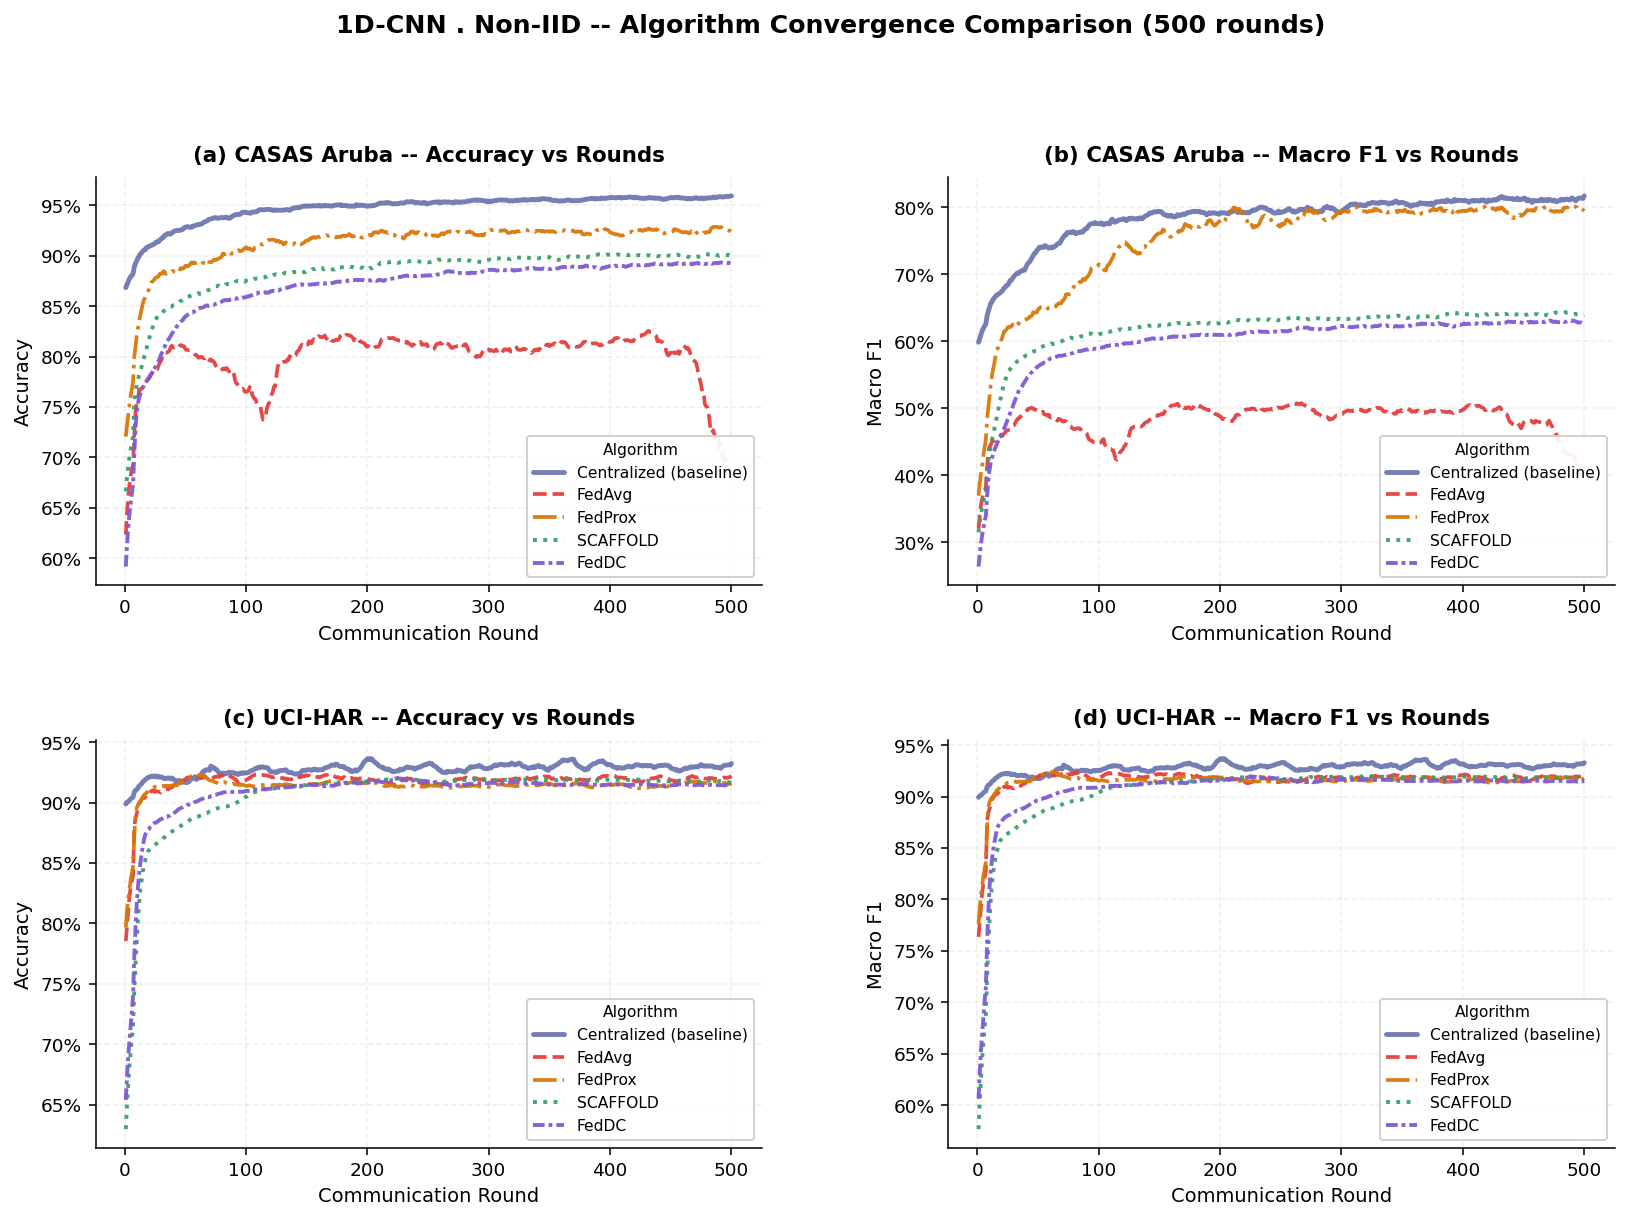

In [6]:
# Load Non-IID data for both datasets
print("Loading CASAS Non-IID...")
dfs_casas_noniid = load_dfs("casas", "non_iid")

print("\nLoading UCI Non-IID...")
dfs_uci_noniid = load_dfs("uci", "non_iid")

# Figure A -- convergence curves (place BEFORE result table in thesis)
plot_combined_noniid(dfs_casas_noniid, dfs_uci_noniid)


## Step 2 — Generate Figure B (bar chart comparison)
> Place Figure B **after** the result table in thesis Section 5.1.1


Saved -> results/plots/1dcnn_noniid_bar_comparison.png


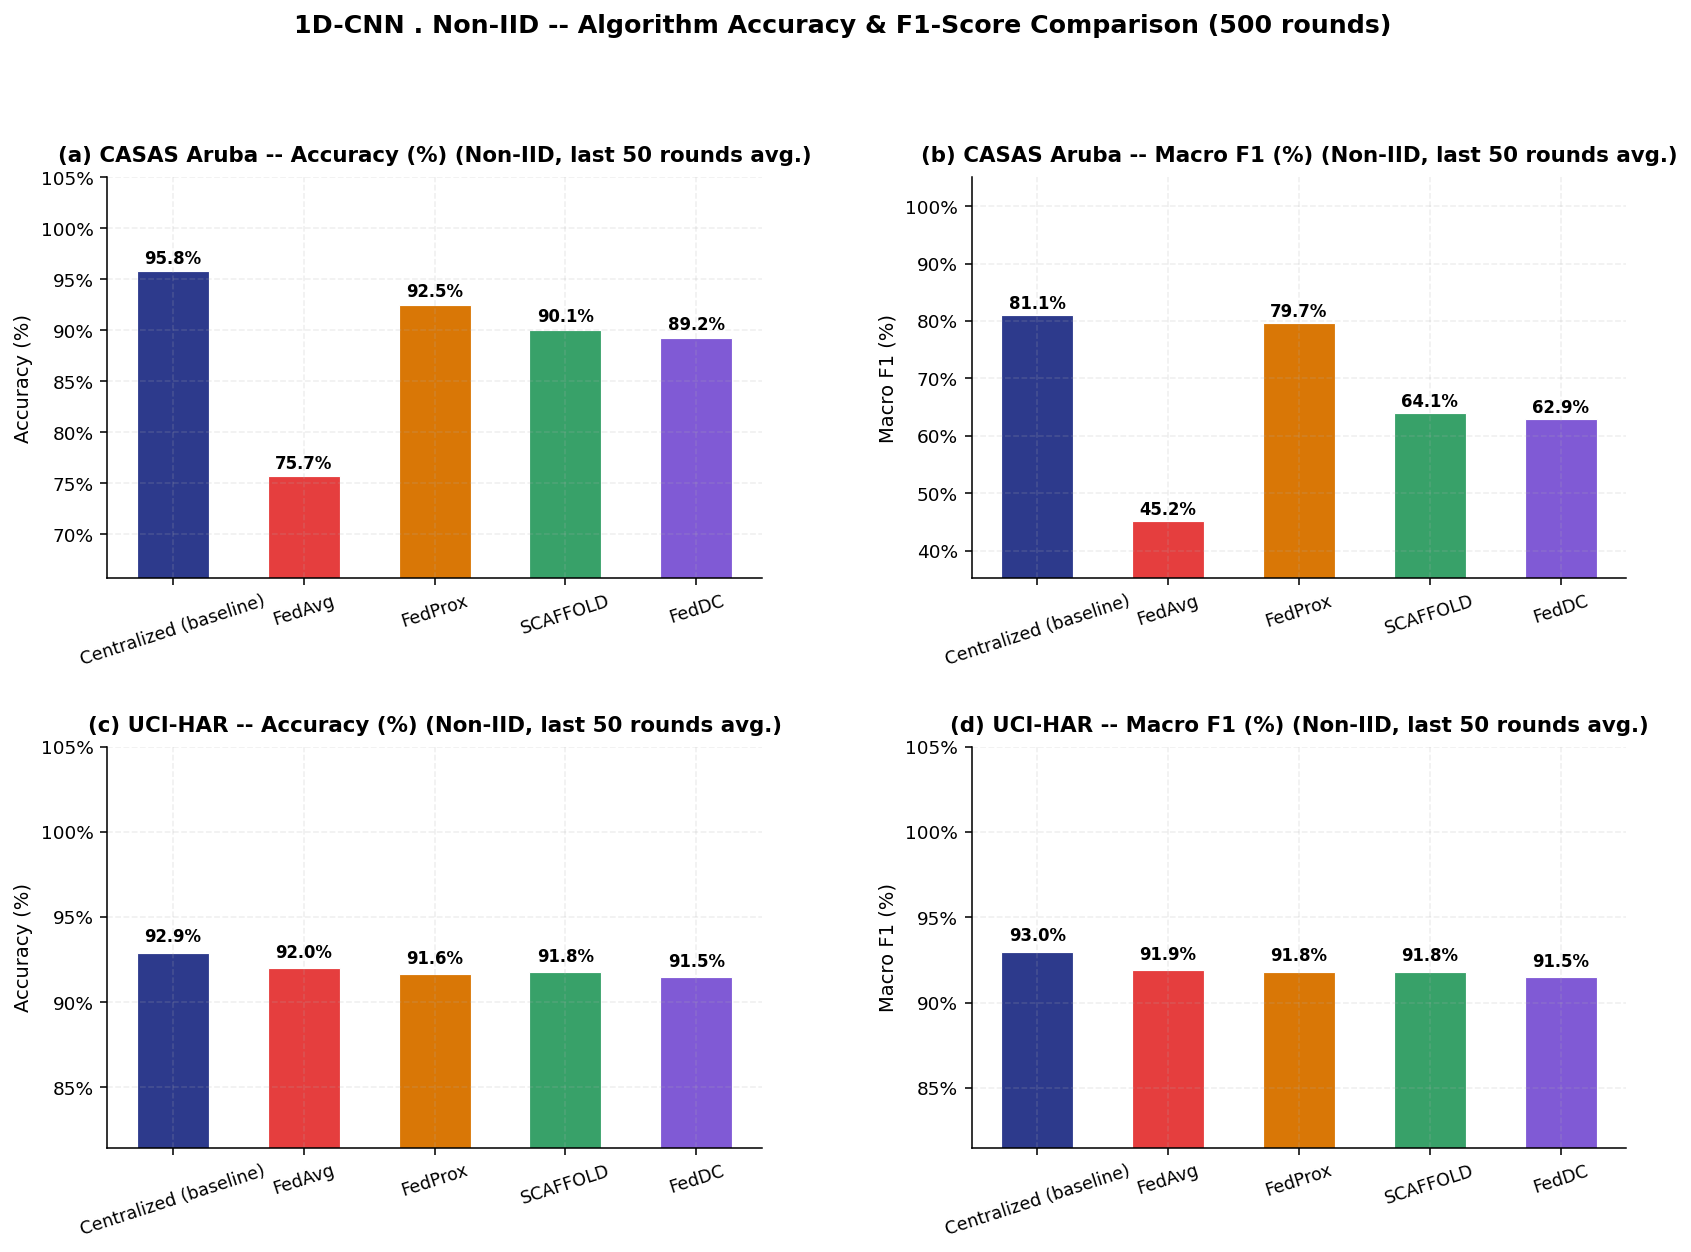

In [7]:
# Figure B -- bar chart comparison (place AFTER result table in thesis)
plot_noniid_bar_comparison(dfs_casas_noniid, dfs_uci_noniid)


## IID Reference (not included as thesis figures)


In [4]:
# IID experiments -- kept for reference, not shown as thesis figures
# Uncomment to regenerate if needed:
# print("Loading CASAS IID..."); dfs_casas_iid = load_dfs("casas", "iid")
# print("Loading UCI IID...");   dfs_uci_iid   = load_dfs("uci",   "iid")
# plot_combined_noniid(dfs_casas_iid, dfs_uci_iid)
# plot_noniid_bar_comparison(dfs_casas_iid, dfs_uci_iid)
